In [1]:
import pandas as pd

import numpy as np

sales = pd.read_csv("https://raw.githubusercontent.com/aric-labarr/ban6025-data/main/marketing_data.csv")

tele = pd.read_csv("https://raw.githubusercontent.com/aric-labarr/ban6025-data/main/tele_churn3.csv")

In [2]:
sales.head(3)

,Campaign_Name,Day,Spend_USD,Num_Cart_Adds,Num_Purchase,Num_Impressions,Num_Website_Clicks,Num_Views
0,Control Campaign,1,3008,894,255,39550,3038,1069
1,Control Campaign,2,2542,879,677,100719,4657,1548
2,Control Campaign,3,2365,1268,578,70263,7885,2367


In [3]:
tele.head(3)

,account length,international plan,voice mail plan,total day charge,total intl calls,customer service calls,churn
0,48,0,0,33.69,5,1,0
1,76,0,0,31.64,4,0,0
2,128,0,0,25.25,2,1,0


### Questions 1-9

In [4]:
#1
tele.columns

Index(['account length', 'international plan', 'voice mail plan',
       'total day charge', 'total intl calls', 'customer service calls',
       'churn'],
      dtype='object')

In [5]:
#2
churn_prop = pd.crosstab(index = tele['churn'], columns = "prop")/pd.crosstab(index = tele['churn'], columns = "prop").sum()
print(churn_prop)

col_0      prop
churn          
0      0.883598
1      0.116402


In [6]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

train_t, test_t = train_test_split(tele, test_size = 0.25, random_state = 8675309)

predictors = train_t.drop(columns = ['churn'])

X = predictors
y = train_t['churn']

In [7]:
X.head(3)

,account length,international plan,voice mail plan,total day charge,total intl calls,customer service calls
402,115,0,0,35.80,5,0
26,177,0,1,39.13,2,1
636,136,0,0,18.60,5,0


In [8]:
#3 
X = sm.add_constant(X)

# Build Logistic Regression
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.284044
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                  992
Model:                          Logit   Df Residuals:                      985
Method:                           MLE   Df Model:                            6
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.1990
Time:                        10:15:39   Log-Likelihood:                -281.77
converged:                       True   LL-Null:                       -351.78
Covariance Type:            nonrobust   LLR p-value:                 9.957e-28
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -5.2624      0.591     -8.911      0.000      -6.420      

In [9]:
#6
import math
print(math.exp(-0.5691))

0.5660346407008962


In [10]:
#7
from sklearn.metrics import roc_auc_score

train_t['p_hat'] = result.predict()

auc = roc_auc_score(y, train_t['p_hat'])
print("C-statistic (AUC):", auc)

C-statistic (AUC): 0.8171997543467537


### Questions 10-18

In [11]:
sales.head(20)

,Campaign_Name,Day,Spend_USD,Num_Cart_Adds,Num_Purchase,Num_Impressions,Num_Website_Clicks,Num_Views
0,Control Campaign,1,3008,894,255,39550,3038,1069
1,Control Campaign,2,2542,879,677,100719,4657,1548
2,Control Campaign,3,2365,1268,578,70263,7885,2367
3,Control Campaign,4,2710,566,340,78451,4216,1437
4,Control Campaign,5,2297,956,768,114295,5863,858
5,Control Campaign,6,2458,882,488,42684,7488,1073
6,Control Campaign,7,2838,1301,890,53986,4221,2182
7,Control Campaign,8,2916,1240,431,33669,7184,2194
8,Control Campaign,9,2652,1200,845,45511,8259,2761
9,Control Campaign,10,2790,424,275,95054,8125,1804


In [20]:
from sklearn.model_selection import train_test_split

sales_dummy = pd.get_dummies(sales, drop_first = True).astype(float)

train_s, test_s = train_test_split(sales_dummy, test_size = 0.25, random_state = 8675309)

predictors = train_s.drop(columns = ['Num_Purchase'])

X = predictors
y = train_s['Num_Purchase']

y_test = test_s['Num_Purchase']
X_test = test_s.drop('Num_Purchase', axis=1)

In [13]:
#12

# ================
# DECISION TREE OPTIMIZE --> GRID SEARCH
# ================
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV, KFold

# Define parameter grid
param_grid = {
    'max_depth': [4,5],
    'min_samples_split': [5,10],
    'min_samples_leaf': [5,10]
}

cv = KFold(n_splits = 5, shuffle = True, random_state = 8675309)

# Initialize regressor
dt = DecisionTreeRegressor(random_state = 8675309)

# Grid search with cross-validation
grid_search_reg = GridSearchCV(dt, param_grid = param_grid, cv = cv, scoring='neg_mean_squared_error')
grid_search_reg.fit(X, y)

# Best estimator and score
print("Best Regressor Params:", grid_search_reg.best_params_)

Best Regressor Params: {'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 5}


In [14]:
# ================
# DECISION TREE MODEL W OPTIMIZED SOLUTION
# ================
dt_sales = DecisionTreeRegressor(random_state = 8675309, 
                                max_depth = 4,
                                min_samples_split = 5, 
                                min_samples_leaf = 5)
dt_sales.fit(X, y)

DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, min_samples_split=5,
                      random_state=8675309)

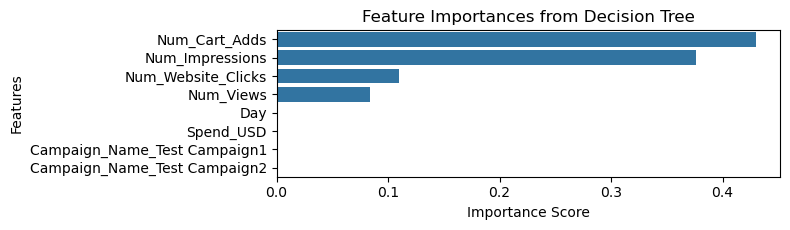

Num_Cart_Adds                   0.430048
Num_Impressions                 0.376589
Num_Website_Clicks              0.109643
Num_Views                       0.083721
Day                             0.000000
Spend_USD                       0.000000
Campaign_Name_Test Campaign1    0.000000
Campaign_Name_Test Campaign2    0.000000
dtype: float64


In [15]:
#15

# ================
# FEATURE IMPORTANCE
# ================

import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances
importances = dt_sales.feature_importances_

# Create a Series with feature names and their importance scores then sort
feature_importances = pd.Series(importances, index = X.columns)
sorted_importances = feature_importances.sort_values(ascending = False)

# Plot
plt.figure(figsize=(8, len(sorted_importances) * 0.3))  # dynamic height
sns.barplot(x=sorted_importances.values, y=sorted_importances.index)
plt.title("Feature Importances from Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

print(sorted_importances)

In [16]:
#17

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

dt_pred = dt_sales.predict(X_test)

mae = mean_absolute_error(y_test, dt_pred)
mape = mean_absolute_percentage_error(y_test, dt_pred)

print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

MAE: 119.73
MAPE: 26.76%


In [24]:
#19
# ================
# ELASTIC NET
# ================
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

# Standardize all variables
scaler = StandardScaler()
X_standard = scaler.fit_transform(X)
X_standard = pd.DataFrame(X_standard, 
                                   columns = X.columns, 
                                   index = X.index)

# Set up ElasticNetCV with a grid of alphas and l1_ratios
elastic_cv = ElasticNetCV(
    alphas=np.logspace(-4, 4, 100),   # range of alpha (lambda) values
    l1_ratio=[0.001, 0.01, 0.1, 0.5, 0.7, 0.9, 1.0],  # try different L1 ratios
    cv=5,
    random_state=8675309,
    max_iter=100000
)

# Fit the model
elastic_cv.fit(X_standard, y)

# Best parameters
print(f"Best alpha (lambda): {elastic_cv.alpha_:.5f}")
print(f"Best l1_ratio: {elastic_cv.l1_ratio_}")

Best alpha (lambda): 21.54435
Best l1_ratio: 1.0


In [28]:
#20
X_test_standard = scaler.transform(X_test)
X_test_standard = pd.DataFrame(X_test_standard, 
                                   columns = X_test.columns, 
                                   index = X_test.index)

en_pred = elastic_cv.predict(X_test_standard)

mae = mean_absolute_error(y_test, en_pred)
mape = mean_absolute_percentage_error(y_test, en_pred)

print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

MAE: 117.09
MAPE: 26.34%


In [19]:
# ================
# NEURAL NETWORK
# ================

# =================
# STANDARDIZE DATA
# =================
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler 

unique_counts = X.nunique()

continuous_features = unique_counts[unique_counts > 2].index.tolist()
binary_features = unique_counts[unique_counts == 2].index.tolist()

final_feature_order = continuous_features + binary_features

scaler = StandardScaler()

X_cont_scaled = scaler.fit_transform(X[continuous_features])

X_binary = X[binary_features].values

X_scaled = np.hstack((X_cont_scaled, X_binary))

X_scaled_df = pd.DataFrame(X_scaled, columns=final_feature_order)

# =================
# OPTIMIZE -> GRID SEARCH
# =================
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    'alpha': [0.001, 0.01],
    'activation': ['relu'],
    'hidden_layer_sizes': [(50,), (75,), (75,50)],
}

cv = KFold(n_splits = 5, shuffle = True, random_state = 8675309)

nn = MLPRegressor(max_iter = 100000, solver = 'adam', random_state = 8675309, early_stopping = True)

grid_search = GridSearchCV(estimator = nn, 
                           param_grid = param_grid, 
                           cv = cv, 
                           scoring = 'neg_mean_squared_error')

grid_search.fit(X_scaled_df, y)

grid_search.best_params_

{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,)}

In [29]:
# =================
# BUILD MODEL
# =================

nn_sales = MLPRegressor(max_iter = 100000, solver = 'adam',
                       alpha = 0.01,
                       activation = 'relu',
                       hidden_layer_sizes = (50,),
                       random_state = 8675309)
                       
nn_sales.fit(X_scaled_df, y)

MLPRegressor(alpha=0.01, hidden_layer_sizes=(50,), max_iter=100000,
             random_state=8675309)